# Machine Learning Models 01: Linear Regression

Hi there!

This tutorial will be a step-by-step guide to implementing a linear regression model from scratch using PyTorch. 

Here is a list of what we are going to cover:
1. prepare and load data
2. build model
3. model training
4. make predictions and evaluate 

In [1]:
# Importing Libraries
import sys
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

# Checking Python version | package manager | 
print(f"Python {sys.version}\n")

# Checking PyTorch version
print(f"PyTorch Version: {torch.__version__}")

Python 3.9.13 | packaged by conda-forge | (main, May 27 2022, 17:00:33) 
[Clang 13.0.1 ]

PyTorch Version: 1.14.0.dev20221016


## 1. Preparing and loading the data

In linear regression, we want to predict a numeric continuous variable.

To showcase this, let's create a dummy dataset using linear regression formula with known parameters.

We'll then split our dataset into training and test set.

In [2]:
# Known parameters
weight = 0.7
bias = 0.3

# Create range of values
start = 0
end = 1
step = 0.02

# X features
X = torch.arange(start,end,step).unsqueeze(dim = 1) 

# y labels
y = weight * X + bias 

# Checking the first 10 samples
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
# Split the data 80/20
train_split = int(0.8 * len(X))

# Train set
X_train, y_train = X[:train_split], y[:train_split]

# Validation set
X_val, y_val = X[train_split:], y[train_split:]

# Verifying train and test set size
len(X_train), len(y_train), len(X_val), len(y_val)

(40, 40, 10, 10)

In [4]:
# Plot predictions
def plot_predictions(X_train = X_train, y_train = y_train,
                     X_val = X_val, y_val = y_val,
                     predictions = None):
    """
    Plots training set, test set and compares predictions.
    """

    plt.figure(figsize=(10,7))

    # Plot training set
    plt.scatter(X_train, y_train, c ='r', s = 4, label = "Training data")
    
    # Plot validation set 
    plt.scatter(X_val, y_val, c ='g', s = 4, label = "Validation data")
    
    # Plot predictions
    if predictions is not None:
        plt.scatter(X_val, predictions, c ='b', s = 4, label = "Predictions")
        
    # Show the legend
    plt.legend(prop={"size": 14});

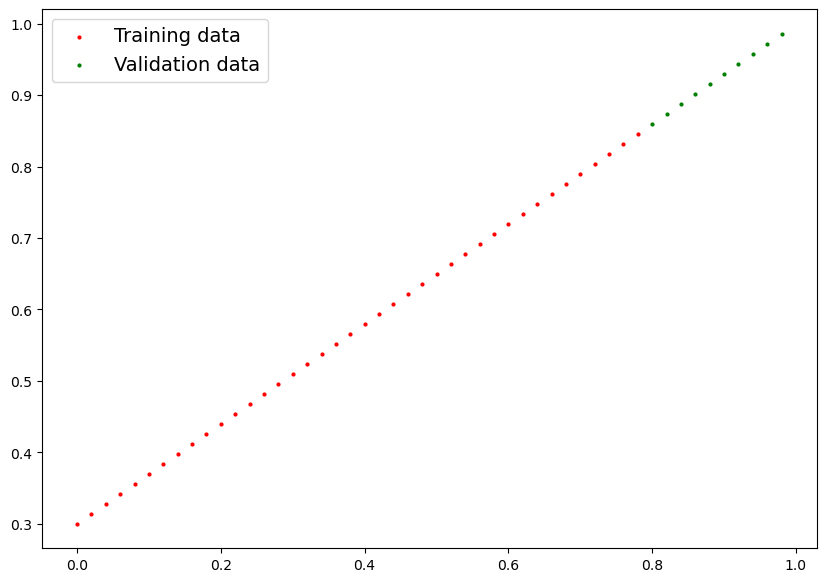

In [5]:
plot_predictions(X_train,y_train,X_val,y_val)

## 2. Building a Linear Regreesion Model

To build our model we will first randomly initialize out model's parameters, and create a forward pass.

In [6]:
# Create a linear model by subclassing nn.Module
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        # Defining weight parameter
        self.weights = nn.Parameter(torch.randn(1, # start with random weights
                                                requires_grad = True, # requires gradient descent
                                                dtype = torch.float))
        # Defining bias parameter
        self.bias = nn.Parameter(torch.randn(1,  #start with random bias
                                             requires_grad = True, 
                                             dtype = torch.float))
        
    # Forward method to define the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # x is the input data of tensor typer
        return self.weights * x + self.bias # linear regression

In [7]:
# Set manual seed
torch.manual_seed(42)

# Create instance of the model
model = LinearRegression()

# Checking the parameters
model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## 3. Training
During the training step our model will learn the best parameters given training data examples.

One way to measure the model's performance over the predictions is to use a loss function.

* **Loss function/Criterion:** A function to measure the difference between actual outputs and predicted outputs.

* **Optmizer:** Adjusts the model's parameters (e.g. weight & bias) to minimize the loss function and return the best parameters.

In [8]:
# Mean absolute error
class MAELoss(nn.Module):
    def forward(self, predicted, actual) -> torch.Tensor:
        return torch.mean(torch.abs(predicted - actual))  # MAE loss


# Setup a criterion
criterion = MAELoss()

# Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model.parameters(),  # Optimize model's parameters
                            lr=0.01)  # Learning rate

In [9]:
torch.manual_seed(42)

# Setting the number of epochs
epochs = 200

# Tracking values
epoch_count = []
train_loss_values = []
val_loss_values = []

# Training
for epoch in range(epochs): 
    # Set model to training mode
    model.train() 
    
    # Forward pass
    y_pred = model(X_train)
    
    # Loss
    train_loss = criterion(y_pred, y_train)
    
    # Backward prop and optimizer
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()  # perform gradient descent
    
    # Evaluation step
    model.eval()  # Set model to evaluation mode
    with torch.inference_mode(): 
        
        # Forward pass
        val_pred = model(X_val)
        
        # Loss
        val_loss = criterion(val_pred,y_val)
    
    # Printing results
    if (epoch + 1) % 5 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(train_loss)
        val_loss_values.append(val_loss)
        
        print(f"Epoch: {epoch + 1}/{epochs} | Train loss: {train_loss} | Val loss: {val_loss}")
        
        print(model.state_dict())
        
        print("\n")
        

Epoch: 5/200 | Train loss: 0.26679736375808716 | Val loss: 0.4271811842918396
OrderedDict([('weights', tensor([0.3562])), ('bias', tensor([0.1788]))])


Epoch: 10/200 | Train loss: 0.20919232070446014 | Val loss: 0.3598262071609497
OrderedDict([('weights', tensor([0.3757])), ('bias', tensor([0.2288]))])


Epoch: 15/200 | Train loss: 0.1515873372554779 | Val loss: 0.2924712300300598
OrderedDict([('weights', tensor([0.3952])), ('bias', tensor([0.2788]))])


Epoch: 20/200 | Train loss: 0.09681282937526703 | Val loss: 0.22817862033843994
OrderedDict([('weights', tensor([0.4146])), ('bias', tensor([0.3258]))])


Epoch: 25/200 | Train loss: 0.06747636198997498 | Val loss: 0.18101617693901062
OrderedDict([('weights', tensor([0.4328])), ('bias', tensor([0.3568]))])


Epoch: 30/200 | Train loss: 0.0545857734978199 | Val loss: 0.14967669546604156
OrderedDict([('weights', tensor([0.4483])), ('bias', tensor([0.3743]))])


Epoch: 35/200 | Train loss: 0.04895269125699997 | Val loss: 0.12895536422729

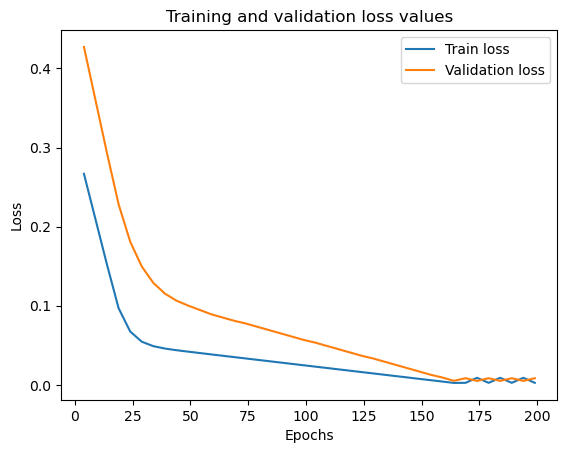

In [10]:
# Verifying results
import numpy as np
import matplotlib.pyplot as plt

# Plot loss curve
plt.plot(epoch_count, np.array(torch.tensor(train_loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, np.array(torch.tensor(val_loss_values).numpy()), label="Validation loss")
plt.title("Training and validation loss values")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

## 4. Saving the Model

In [ ]:
# Save the model state dict
torch.save(model.state_dict(), 'linear-regression.pt')